# Redes de pases antes del primer cambio
match_id=18245

In [595]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch, Sbopen
import pandas as pd

In [596]:
parser = Sbopen()
df, related, freeze, tactics = parser.event(18245)

In [656]:
df.head(2)

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,pass_miscommunication,shot_one_on_one,block_offensive,shot_redirect,foul_committed_advantage,foul_won_advantage,pass_goal_assist,foul_committed_card_id,foul_committed_card_name,injury_stoppage_in_chain
0,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,1,1,00:00:00,0,0,1,0.0,18245,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eaa65a92-02d3-4375-b2b7-7c2f679a620c,2,1,00:00:00,0,0,1,0.0,18245,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [597]:
#avisamos a python de dónde empiezan los substitutos para que no los añada al gráfico de pases
sub = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[0]["index"]

#convertimos el archivo al dato de pases correctos de Real Madrid antes de los cambios
mask_cdm = (df["type_name"] == 'Pass') & (df["team_name"] == "Real Madrid") & (df.index < sub) & (df["outcome_name"].isnull())

#añadimos las columnas que son necesarias para crear la red de pases
df_pass = df.loc[mask_cdm, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]

#hacemos que sólo aparezcan los apellidos de los jugadores
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

In [598]:
players11_rm = df_pass['player_name'].unique()
players11_rm

array(['Varane', 'Modrić', 'Ramos', 'Júnior', 'Casimiro', 'Kroos',
       'García', 'Aveiro', 'Benzema', 'Gamboa', 'Suárez'], dtype=object)

In [599]:
# Name mapping dictionary
nombre_mapeo = {
    'Varane': 'Varane',
    'Modrić': 'Modric',
    'Júnior': 'Marcelo',
    'Ramos': 'Carvajal',
    'Casimiro': 'Casemiro',
    'García': 'Ramos',
    'Aveiro': 'Cristiano Ronaldo',
    'Benzema': 'Benzema',
    'Gamboa': 'Keylor Navas',
    'Suárez': 'Isco',
    # Add more mappings as needed
}

# Apply the mapping to both columns
df_pass["player_name"] = df_pass["player_name"].map(nombre_mapeo).fillna(df_pass["player_name"])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].map(nombre_mapeo).fillna(df_pass["pass_recipient_name"])


In [600]:
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass["player_name"].unique()):
    passx = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    recx = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    recy = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name

    # nos aseguramos de que la localización de cada jugador, es su media de pases y de recepciones
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))

    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

# ajustamos el tamaño del círculo para que sea más grande cuando más pases da ese jugador
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max()) * 1500

In [601]:
#contar los pases entre un jugador y otro

df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x': 'pass_count'}, axis='columns', inplace=True)

lines_df = lines_df[lines_df['pass_count'] > 2]

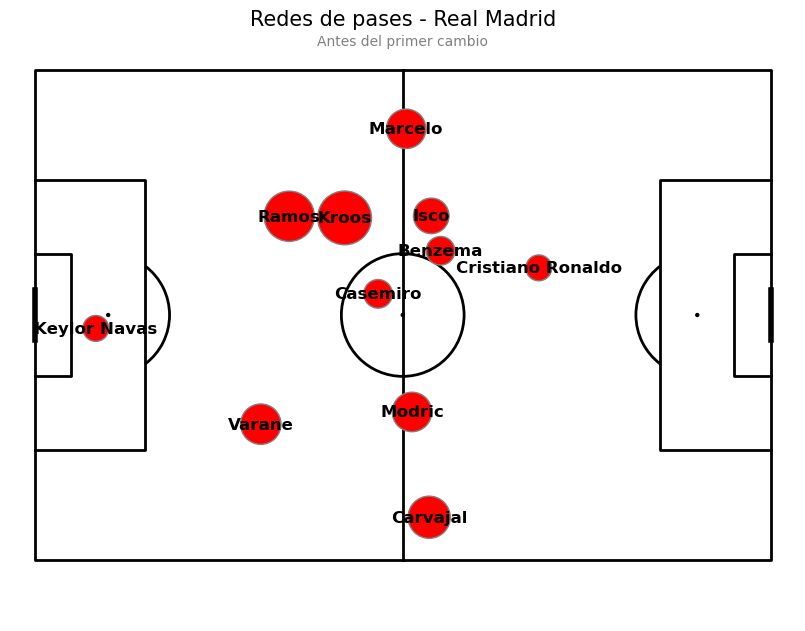

In [602]:
#dibujo del terreno de juego

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.6, title_height=0.06, axis=False,
                    endnote_height=0.04, title_space=-0.3, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

# diseño del tipo de letra del jugador

for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight="bold", size=12, ax=ax["pitch"], zorder = 4)

fig.suptitle("Redes de pases - Real Madrid", fontsize=15)
fig.text(0.5, 0.94, "Antes del primer cambio", ha='center', fontsize=10, color='gray') # Change X and Y.

plt.show()

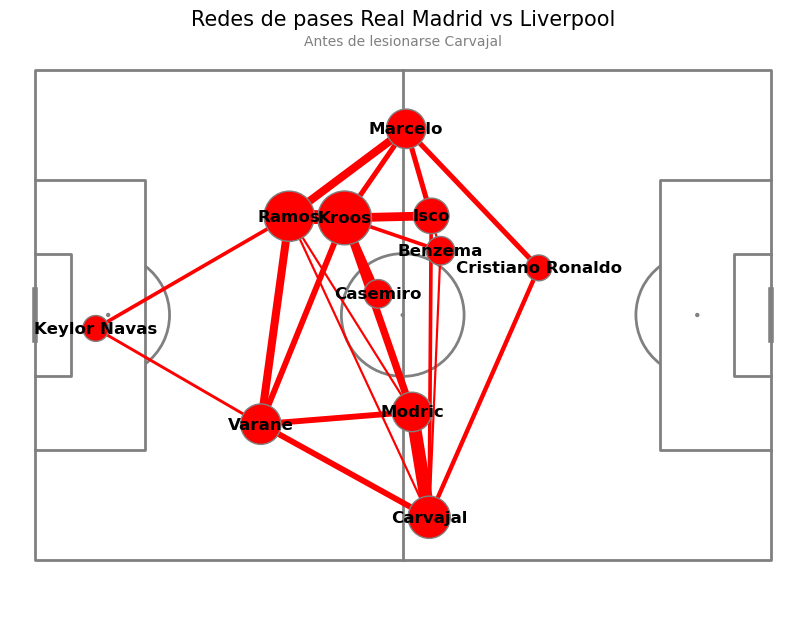

In [603]:
#generar las líneas de los pases

pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.6, title_height=0.06, axis=False,
                    endnote_height=0.04, title_space=-0.3, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight="bold", size=12, ax=ax["pitch"], zorder = 4 )

for i, row in lines_df.iterrows():
    player1 = row["pair_key"].split("_")[0]
    player2 = row["pair_key"].split("_")[1]

    player1_x = scatter_df.loc[scatter_df["player_name"] == player1]["x"].iloc[0]
    player1_y = scatter_df.loc[scatter_df["player_name"] == player1]["y"].iloc[0]
    player2_x = scatter_df.loc[scatter_df["player_name"] == player2]["x"].iloc[0]
    player2_y = scatter_df.loc[scatter_df["player_name"] == player2]["y"].iloc[0]
    num_passes = row["pass_count"]

    line_width = (num_passes / lines_df['pass_count'].max()) * 10

    pitch.lines(player1_x, player1_y, player2_x, player2_y,
                alpha=1, lw=line_width, zorder=2, color="red", ax=ax["pitch"])

fig.suptitle("Redes de pases Real Madrid vs Liverpool", fontsize=15)
# Subtitle
fig.text(0.5, 0.94, "Antes de lesionarse Carvajal", ha='center', fontsize=10, color='gray') # Change X and Y.
plt.show()

In [604]:
# Count passes made by Keylor Navas
navas_passes_count = len(df_pass[df_pass['player_name'] == 'Keylor Navas'])

# Print the result
print(f"Keylor Navas made {navas_passes_count} passes.")

#If you want to count the passes where he was the recipient.
navas_received_passes_count = len(df_pass[df_pass['pass_recipient_name'] == 'Keylor Navas'])

print(f"Keylor Navas received {navas_received_passes_count} passes.")

#If you want to count the total of passes where he was involved.
navas_total_passes_involved = navas_passes_count + navas_received_passes_count

print(f"Keylor Navas was involved in {navas_total_passes_involved} passes.")

Keylor Navas made 9 passes.
Keylor Navas received 5 passes.
Keylor Navas was involved in 14 passes.


# Redes de pases antes desde que entra Nacho por Carvajal

In [606]:
# Find the first substitution row
first_substitution_row = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[0]

# Extract the minute (assuming a "minute" column exists)
substitution_minute = first_substitution_row["minute"]

# Print the minute
print(f"Minute of the first substitution: {substitution_minute}")

Minute of the first substitution: 36


In [607]:
# Find the indices of the first and second substitutions
sub1 = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[0]["index"]
sub2 = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[1]["index"]

# Create the mask for passes between substitutions
mask_cdm = (df["type_name"] == 'Pass') & (df["team_name"] == "Real Madrid") & (df.index > sub1) & (df.index < sub2) & (df["outcome_name"].isnull())

# Create the DataFrame of passes
df_pass = df.loc[mask_cdm, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]

# Extract player last names
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

# Print the first few rows to verify
print(df_pass.head())

         x     y  end_x  end_y player_name pass_recipient_name
1435  15.4  43.6   35.3   16.2      Gamboa              Júnior
1438  47.0  11.1   54.7   23.2      Júnior               Kroos
1441  55.7  22.1   56.1    9.7       Kroos              Júnior
1444  59.8   9.8   70.0    5.6      Júnior              Aveiro
1446  71.2   5.9   76.0   12.5      Aveiro             Benzema


In [608]:
# Name mapping dictionary
nombre_mapeo = {
    'Varane': 'Varane',
    'Modrić': 'Modric',
    'Júnior': 'Marcelo',
    'Iglesias': 'Nacho',
    'Casimiro': 'Casemiro',
    'García': 'Ramos',
    'Aveiro': 'Cristiano Ronaldo',
    'Benzema': 'Benzema',
    'Gamboa': 'Keylor Navas',
    'Suárez': 'Isco',
    # Add more mappings as needed
}

# Apply the mapping to both columns
df_pass["player_name"] = df_pass["player_name"].map(nombre_mapeo).fillna(df_pass["player_name"])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].map(nombre_mapeo).fillna(df_pass["pass_recipient_name"])


In [609]:
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass["player_name"].unique()):
    passx = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    recx = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    recy = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name

    # nos aseguramos de que la localización de cada jugador, es su media de pases y de recepciones
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))

    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

# ajustamos el tamaño del círculo para que sea más grande cuando más pases da ese jugador
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max()) * 1500

In [610]:
#contar los pases entre un jugador y otro

df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x': 'pass_count'}, axis='columns', inplace=True)

lines_df = lines_df[lines_df['pass_count'] > 2]

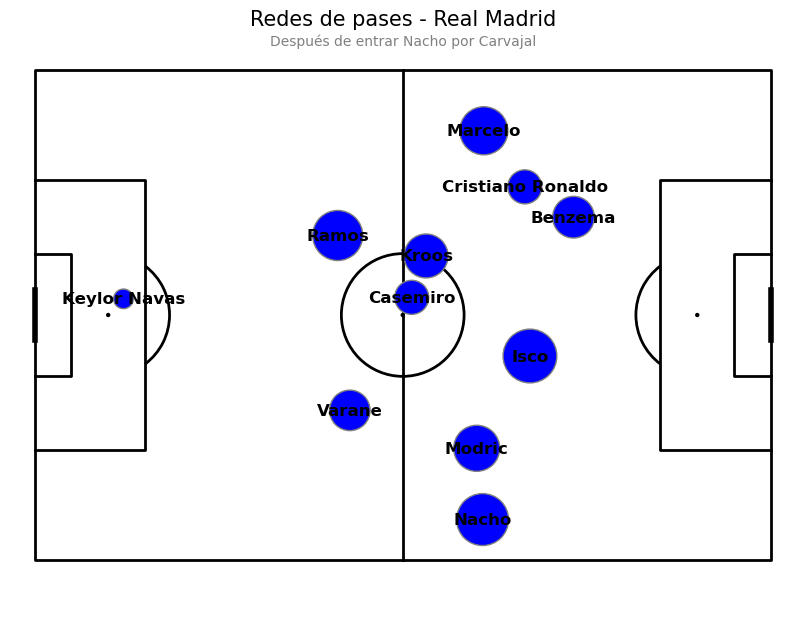

In [611]:
#dibujo del terreno de juego

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.6, title_height=0.06, axis=False,
                    endnote_height=0.04, title_space=-0.3, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='blue', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

# diseño del tipo de letra del jugador

for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight="bold", size=12, ax=ax["pitch"], zorder = 4)

fig.suptitle("Redes de pases - Real Madrid", fontsize=15)
fig.text(0.5, 0.94, "Después de entrar Nacho por Carvajal", ha='center', fontsize=10, color='gray') # Change X and Y.


plt.show()

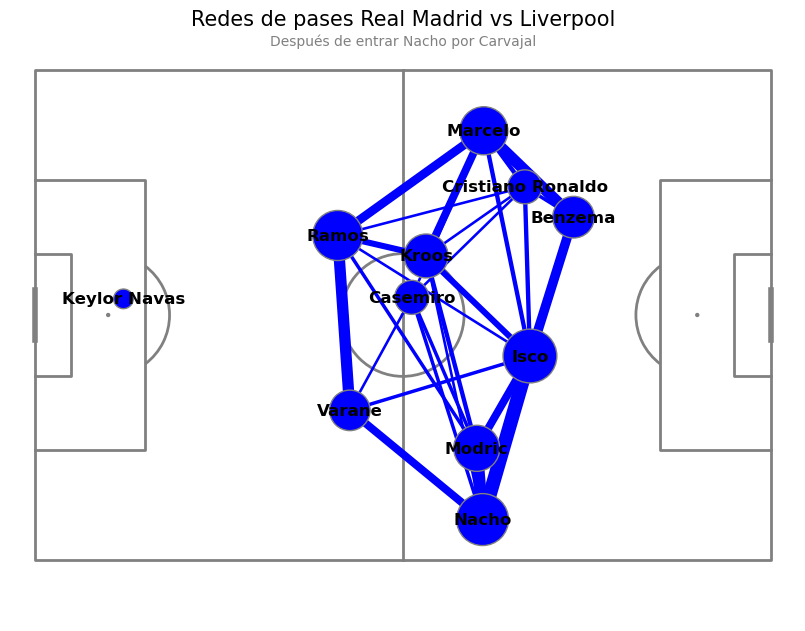

In [612]:
#generar las líneas de los pases
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.6, title_height=0.06, axis=False,
                    endnote_height=0.04, title_space=-0.30, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='blue', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight="bold", size=12, ax=ax["pitch"], zorder = 4 )

for i, row in lines_df.iterrows():
    player1 = row["pair_key"].split("_")[0]
    player2 = row["pair_key"].split("_")[1]

    player1_x = scatter_df.loc[scatter_df["player_name"] == player1]["x"].iloc[0]
    player1_y = scatter_df.loc[scatter_df["player_name"] == player1]["y"].iloc[0]
    player2_x = scatter_df.loc[scatter_df["player_name"] == player2]["x"].iloc[0]
    player2_y = scatter_df.loc[scatter_df["player_name"] == player2]["y"].iloc[0]
    num_passes = row["pass_count"]

    line_width = (num_passes / lines_df['pass_count'].max()) * 10

    pitch.lines(player1_x, player1_y, player2_x, player2_y,
                alpha=1, lw=line_width, zorder=2, color="blue", ax=ax["pitch"])

fig.suptitle("Redes de pases Real Madrid vs Liverpool", fontsize=15)
fig.text(0.5, 0.94, "Después de entrar Nacho por Carvajal", ha='center', fontsize=10, color='gray') # Change X and Y.

plt.show()

In [613]:
# Count passes made by Keylor Navas
navas_passes_count = len(df_pass[df_pass['player_name'] == 'Keylor Navas'])

# Print the result
print(f"Keylor Navas made {navas_passes_count} passes.")

#If you want to count the passes where he was the recipient.
navas_received_passes_count = len(df_pass[df_pass['pass_recipient_name'] == 'Keylor Navas'])

print(f"Keylor Navas received {navas_received_passes_count} passes.")

#If you want to count the total of passes where he was involved.
navas_total_passes_involved = navas_passes_count + navas_received_passes_count

print(f"Keylor Navas was involved in {navas_total_passes_involved} passes.")

Keylor Navas made 4 passes.
Keylor Navas received 3 passes.
Keylor Navas was involved in 7 passes.


# Redes de pases antes desde que entra Bale por Isco

In [615]:
# Find the second substitution row
second_substitution_row = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[1]

# Extract the minute (assuming a "minute" column exists)
substitution_minute = second_substitution_row["minute"]

# Print the minute
print(f"Minute of the second substitution: {substitution_minute}")

Minute of the second substitution: 60


In [616]:
# Find the indices of the second and third substitutions
sub2 = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[1]["index"]
sub3 = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Real Madrid"].iloc[2]["index"]

# Create the mask for passes between substitutions
mask_cdm = (df["type_name"] == 'Pass') & (df["team_name"] == "Real Madrid") & (df.index > sub2) & (df.index < sub3) & (df["outcome_name"].isnull())

# Create the DataFrame of passes
df_pass = df.loc[mask_cdm, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]

# Extract player last names
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

# Print the first few rows to verify
print(df_pass.head())

         x     y  end_x  end_y player_name pass_recipient_name
2438  28.3  72.0   35.2   74.3      Varane            Iglesias
2444  41.7  80.0   56.4   74.3    Iglesias                Bale
2469  35.9  30.7   48.4   30.7      Varane              Modrić
2471  48.4  30.7   44.4   11.6      Modrić              Júnior
2474  62.8  12.1   68.4    1.9      Júnior              Aveiro


In [617]:
# Name mapping dictionary
nombre_mapeo = {
    'Varane': 'Varane',
    'Modrić': 'Modric',
    'Júnior': 'Marcelo',
    'Iglesias': 'Nacho',
    'Casimiro': 'Casemiro',
    'García': 'Ramos',
    'Aveiro': 'Cristiano Ronaldo',
    'Benzema': 'Benzema',
    'Gamboa': 'Keylor Navas',
    'Bale': 'Bale',
    # Add more mappings as needed
}

# Apply the mapping to both columns
df_pass["player_name"] = df_pass["player_name"].map(nombre_mapeo).fillna(df_pass["player_name"])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].map(nombre_mapeo).fillna(df_pass["pass_recipient_name"])


In [618]:
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass["player_name"].unique()):
    passx = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    recx = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    recy = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name

    # nos aseguramos de que la localización de cada jugador, es su media de pases y de recepciones
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))

    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

# ajustamos el tamaño del círculo para que sea más grande cuando más pases da ese jugador
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max()) * 1500

In [619]:
#contar los pases entre un jugador y otro

df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x': 'pass_count'}, axis='columns', inplace=True)

lines_df = lines_df[lines_df['pass_count'] > 2]

In [620]:
lines_df

,pair_key,pass_count
4,Bale_Modric,4
5,Bale_Nacho,4
8,Benzema_Kroos,6
9,Benzema_Marcelo,4
10,Benzema_Modric,3
16,Casemiro_Modric,6
17,Casemiro_Nacho,3
20,Cristiano Ronaldo_Kroos,4
21,Cristiano Ronaldo_Marcelo,17
25,Kroos_Marcelo,11


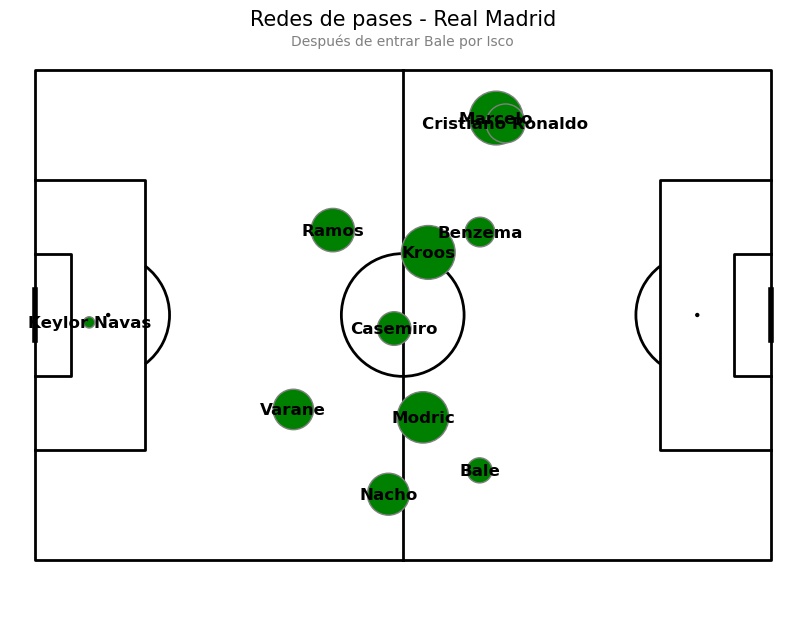

In [621]:
#dibujo del terreno de juego

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.6, title_height=0.06, axis=False,
                    endnote_height=0.04, title_space=-0.30, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='green', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

# diseño del tipo de letra del jugador

for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight="bold", size=12, ax=ax["pitch"], zorder = 4)

fig.suptitle("Redes de pases - Real Madrid", fontsize=15)
fig.text(0.5, 0.94, "Después de entrar Bale por Isco", ha='center', fontsize=10, color='gray') # Change X and Y.

plt.show()

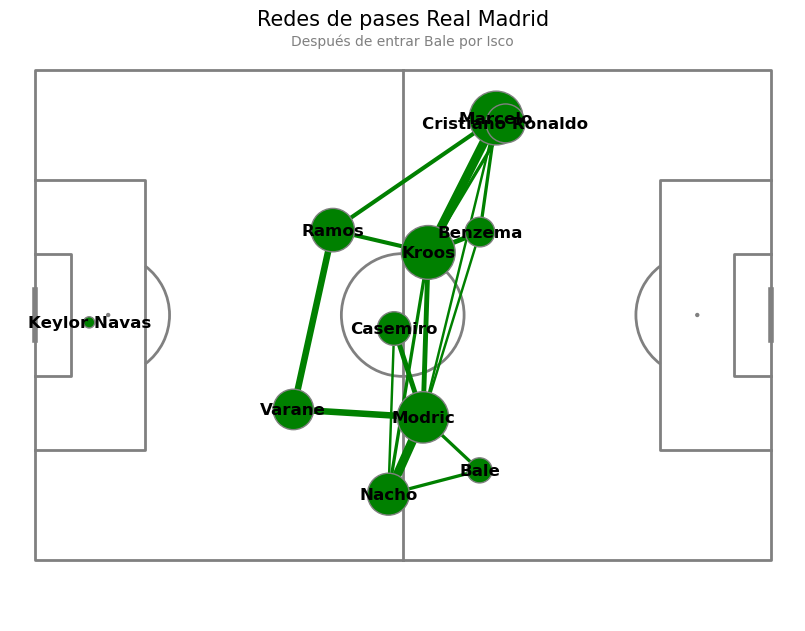

In [622]:
#generar las líneas de los pases

pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.6, title_height=0.06, axis=False,
                    endnote_height=0.04, title_space=-0.30, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='green', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight="bold", size=12, ax=ax["pitch"], zorder = 4 )

for i, row in lines_df.iterrows():
    player1 = row["pair_key"].split("_")[0]
    player2 = row["pair_key"].split("_")[1]

    player1_x = scatter_df.loc[scatter_df["player_name"] == player1]["x"].iloc[0]
    player1_y = scatter_df.loc[scatter_df["player_name"] == player1]["y"].iloc[0]
    player2_x = scatter_df.loc[scatter_df["player_name"] == player2]["x"].iloc[0]
    player2_y = scatter_df.loc[scatter_df["player_name"] == player2]["y"].iloc[0]
    num_passes = row["pass_count"]

    line_width = (num_passes / lines_df['pass_count'].max()) * 10

    pitch.lines(player1_x, player1_y, player2_x, player2_y,
                alpha=1, lw=line_width, zorder=2, color="green", ax=ax["pitch"])

fig.suptitle("Redes de pases Real Madrid", fontsize=15)
fig.text(0.5, 0.94, "Después de entrar Bale por Isco", ha='center', fontsize=10, color='gray') # Change X and Y.

plt.show()

In [623]:
# Count passes made by Keylor Navas
navas_passes_count = len(df_pass[df_pass['player_name'] == 'Keylor Navas'])

# Print the result
print(f"Keylor Navas made {navas_passes_count} passes.")

#If you want to count the passes where he was the recipient.
navas_received_passes_count = len(df_pass[df_pass['pass_recipient_name'] == 'Keylor Navas'])

print(f"Keylor Navas received {navas_received_passes_count} passes.")

#If you want to count the total of passes where he was involved.
navas_total_passes_involved = navas_passes_count + navas_received_passes_count

print(f"Keylor Navas was involved in {navas_total_passes_involved} passes.")

Keylor Navas made 1 passes.
Keylor Navas received 1 passes.
Keylor Navas was involved in 2 passes.
